# A Simulation Study (Exercise) {#sec-simulation-anova-ex}

{{< video ./figures/animations/PopulationSampling.mp4 >}}

{{< video ./figures/animations/GroupDifferenceSampling.mp4 >}}


In [46]:
## Warning: to compile the notes you need the "bookdown" and the "broom" packages. Install them by
## running install.packages, see the commented lines below

if (!require("tidyverse")) {
  install.packages("tidyverse")
}

if (!require("broom")) {
  install.packages("broom")
}

suppressMessages(library(tidyverse))
suppressMessages(library(broom))

In [61]:
N <- 10000
female <- rbinom(N, 1, 0.5)

mu <- 170 - 10 * female
sigma <- 10

height <- rnorm(N, mean=mu, sd=sigma) |> round(0)

pop <- tibble(female, mu, height) |>
    mutate(
        person_id = row_number(),
    )

pop |> head()

female,mu,height,person_id
<int>,<dbl>,<dbl>,<int>
1,160,156,1
1,160,157,2
0,170,185,3
0,170,172,4
1,160,156,5
1,160,162,6


In [62]:
pop |> summary()

     female             mu            height      person_id    
 Min.   :0.0000   Min.   :160.0   Min.   :126   Min.   :    1  
 1st Qu.:0.0000   1st Qu.:160.0   1st Qu.:157   1st Qu.: 2501  
 Median :0.0000   Median :170.0   Median :165   Median : 5000  
 Mean   :0.4946   Mean   :165.1   Mean   :165   Mean   : 5000  
 3rd Qu.:1.0000   3rd Qu.:170.0   3rd Qu.:173   3rd Qu.: 7500  
 Max.   :1.0000   Max.   :170.0   Max.   :207   Max.   :10000  

In [63]:
# Population averages and standard deviations

pop |>
    group_by(female) |>
    summarize(
        n = n(),
        pct = 100 * n / nrow(pop),
        mean = mean(height) |> round(1),
        sd = sd(height) |> round(1)
    )


female,n,pct,mean,sd
<int>,<int>,<dbl>,<dbl>,<dbl>
0,5054,50.54,169.9,10.1
1,4946,49.46,159.9,9.9


In [64]:
generate_samples <- function(pop_dt, sample_size, number_of_samples) {
    samples_list <- replicate(number_of_samples, pop_dt |> slice_sample(n = sample_size), simplify = FALSE)
    samples_dt <- samples_list |> 
        bind_rows(.id = "sample_id")
    return(samples_dt)
}

samples <- generate_samples(pop_dt = pop, sample_size = 2, number_of_samples = 3)
samples

sample_id,female,mu,height,person_id
<chr>,<int>,<dbl>,<dbl>,<int>
1,1,160,176,7390
1,0,170,141,5567
2,1,160,185,5015
2,0,170,188,2846
3,0,170,180,5709
3,1,160,150,872


In [50]:
# Compute the difference between the group averages in each sample

group_averages_by_sample <- samples |>
    group_by(sample_id, female) |>
    summarize(
        height_avg = mean(height) |> round(1)
    )

group_averages_by_sample

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by sample_id and female.
ℹ Output is grouped by sample_id.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(sample_id, female))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


sample_id,female,height_avg
<chr>,<int>,<dbl>
1,1,169
2,0,162
2,1,151
3,0,155
3,1,136


In [59]:
group_avg_diffs <- group_averages_by_sample |>
    group_by(sample_id) |>
    reframe(
        avg_height_diff = diff(height_avg)    
    )

group_avg_diffs

sample_id,avg_height_diff
<chr>,<dbl>
2,-11
3,-19


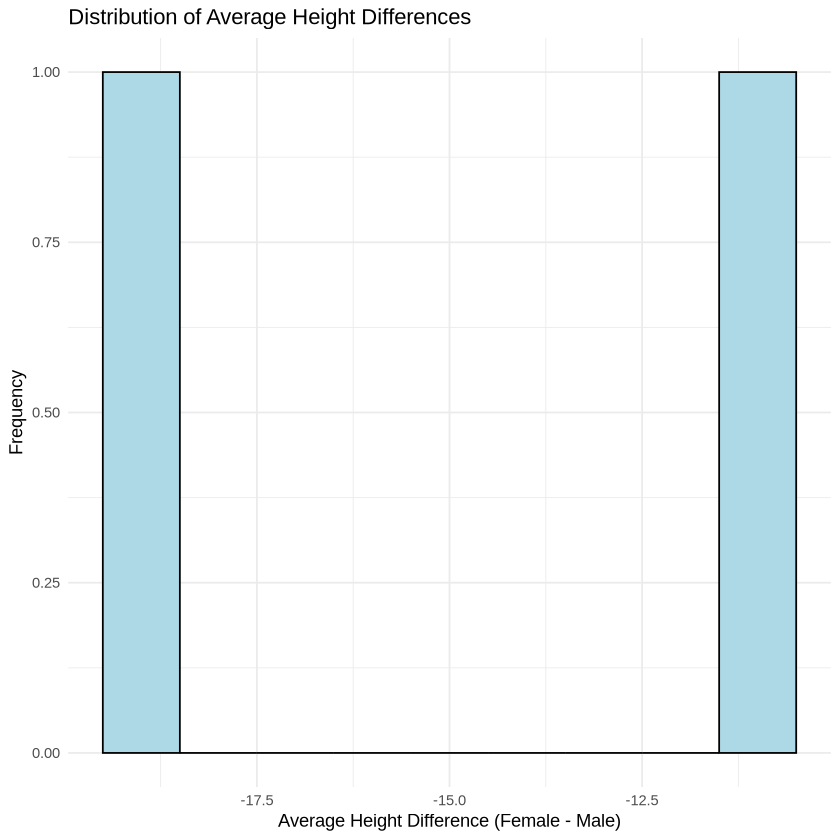

In [ ]:
# Show the distribution of avg_height_diff across samples

group_avg_diffs |>
    ggplot(aes(x = avg_height_diff)) +
    geom_histogram(binwidth = 1, fill = "lightblue", color = "black") +
    labs(
        title = "Distribution of Average Height Differences",
        x = "Average Height Difference (Female - Male)",
        y = "Frequency"
    ) +
    theme_minimal()

In [87]:
simulate_group_diffs <- function(pop_dt, sample_size, number_of_samples) {
    samples <- generate_samples(pop_dt, sample_size, number_of_samples)
    
    # Run a linear regression of height on female in each sample and extract the coefficient using lm

        lm_by_sample <- samples |>
            group_by(sample_id) |>
            group_map(~ {
                model <- lm(height ~  female, data = .x)
                tidy(model)
            }) |>
            bind_rows(.id = "sample_id") |>
            mutate(
                sample_size = sample_size,
                number_of_samples = number_of_samples
            )

    return(lm_by_sample)
}

In [88]:
sim1 <- simulate_group_diffs(
    pop, 
    sample_size = 10, 
    number_of_samples = 1000
)

sim2 <- simulate_group_diffs(
    pop, 
    sample_size = 100, 
    number_of_samples = 1000
)

In [89]:
sim1 |> head()

sample_id,term,estimate,std.error,statistic,p.value,sample_size,number_of_samples
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,(Intercept),164.166667,3.061295,53.6265406,1.621199e-11,10,1000
1,female,3.333333,4.840333,0.6886579,5.105122e-01,10,1000
2,(Intercept),175.000000,4.003254,43.7144396,8.273454e-11,10,1000
2,female,-15.166667,5.168179,-2.9346251,1.886414e-02,10,1000
3,(Intercept),172.000000,4.250919,40.4618388,1.531904e-10,10,1000
3,female,-10.500000,9.505344,-1.1046418,3.014278e-01,10,1000


In [90]:
sim2 |> head()

sample_id,term,estimate,std.error,statistic,p.value,sample_size,number_of_samples
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,(Intercept),169.01639,1.401819,120.569364,2.357895e-108,100,1000
1,female,-10.14460,2.244706,-4.519343,1.735765e-05,100,1000
2,(Intercept),171.90000,1.274257,134.902155,4.171578e-113,100,1000
2,female,-11.28000,1.802071,-6.259464,1.022712e-08,100,1000
3,(Intercept),170.50000,1.311854,129.968725,1.574765e-111,100,1000
3,female,-11.28261,1.934223,-5.833147,7.010407e-08,100,1000


Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_bin()`).”


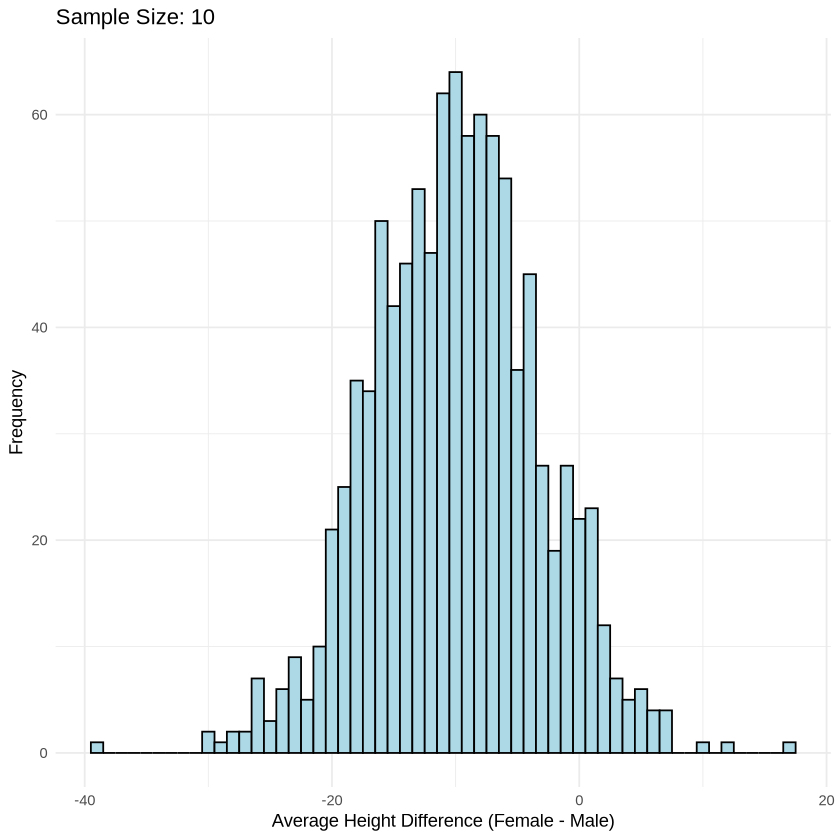

In [94]:
# Visualize the distribution of average height differences for both simulations

sim1 |>
    filter(term == "female") |>
    ggplot(aes(x = estimate)) +
    geom_histogram(binwidth = 1, fill = "lightblue", color = "black") +
    labs(
        title = "Sample Size: 10",
        x = "Average Height Difference (Female - Male)",
        y = "Frequency"
    ) +
    theme_minimal()


Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_bin()`).”


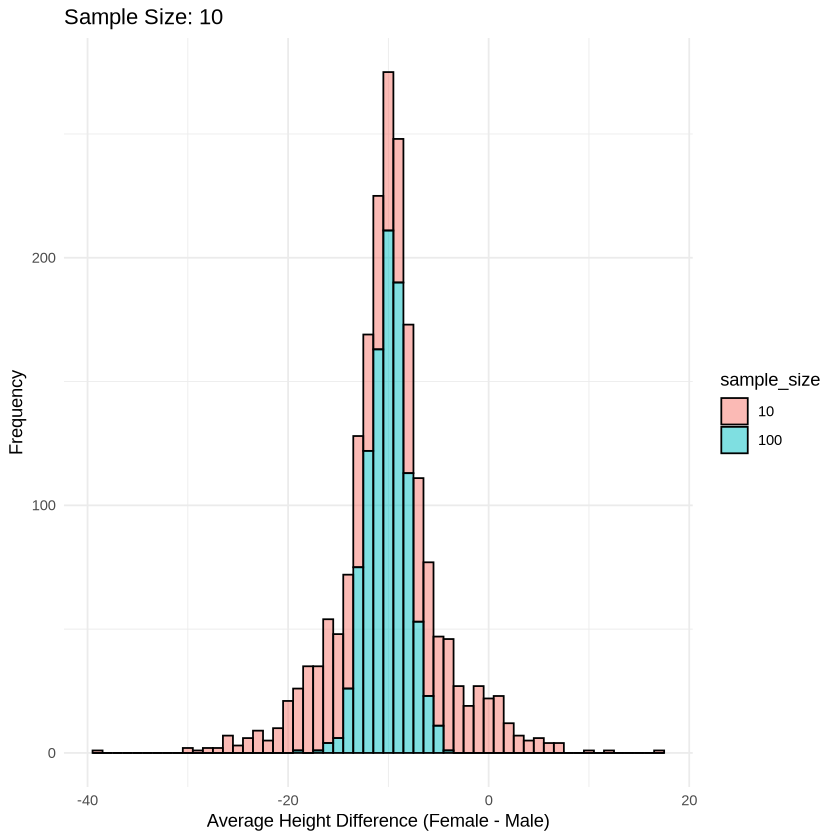

In [98]:
sim1 |> 
    bind_rows(sim2) |>
    filter(term == "female") |>
    mutate(sample_size = as.factor(sample_size)) |>
    ggplot(aes(x = estimate, fill = sample_size)) +
    geom_histogram(binwidth = 1, color = "black", alpha = 0.5) +
    labs(
        title = "Sample Size: 10",
        x = "Average Height Difference (Female - Male)",
        y = "Frequency"
    ) +
    theme_minimal()